# What each additional detection costs

For every extra 50M reads, the cost of that portion of a lane is divided by
the number of genes with AS, or junctions involved in AS, that the extra reads
reveal. Prices are the CCGA Kiel list prices per lane.

Inputs are in `data/derived/cost_counts/`: one file per sample and depth, each line
`<n_subsamples> <n_detections> <expression_level>`. The notebook runs in
seconds.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")
sys.path.insert(0, str(ROOT))
from asdepth import PLATFORM_COLORS

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

DATA = ROOT / "data" / "derived" / "cost_counts"
DEPTHS = np.array([50, 100, 150, 200, 250, 300]) * 1_000_000

# Price per lane in euro and the number of reads a lane yields.
PLATFORMS = {
    "NovaSeq 6000 SP": {"key": "SP", "lane": 2076, "reads": 325_000_000},
    "NovaSeq 6000 S1": {"key": "S1", "lane": 3516, "reads": 650_000_000},
    "NovaSeq 6000 S4": {"key": "S4", "lane": 4516, "reads": 2_000_000_000},
}

HEART = ["J26675", "J26676", "J26677", "J26678"]

# Each panel is (subtitle, samples to average over, kind of detection).
PANELS = [
    (
        "Adipose (post-treatment)",
        [
            ("Per gene", ["Adipose2"], "genes"),
            ("Per junction", ["Adipose2"], "junctions"),
        ],
    ),
    (
        "Heart (DCM), mean of four samples",
        [
            ("Per gene", HEART, "genes"),
            ("Per junction", HEART, "junctions"),
        ],
    ),
]

In [2]:
def total_detections(sample, kind):
    """Total detections at each depth, summed over the three expression levels.

    One input file per depth; `sorted` puts them in ascending depth order
    because the depth index is the second field of the file name.
    """
    paths = sorted(DATA.glob(f"{sample}_*_x_{kind}_in_y_samples"))
    if not paths:
        raise FileNotFoundError(f"no {sample} {kind} counts in {DATA}")

    totals = []
    for path in paths:
        table = pd.read_csv(
            path, sep="\t", header=None,
            names=["subsamples", "detections", "expression"],
        )
        totals.append(table["detections"].sum())
    return np.array(totals)


def cost_per_detection(samples, kind):
    """Euro per additional detection for each platform, at each depth step."""
    detections = np.mean(
        [total_detections(sample, kind) for sample in samples], axis=0
    )
    # A leading zero makes np.diff give the gain over the first 50M as well.
    detections = np.insert(detections, 0, 0)

    costs = {}
    for name, platform in PLATFORMS.items():
        price = platform["lane"] * DEPTHS / platform["reads"]
        price = np.insert(price, 0, 0)
        costs[name] = np.diff(price) / np.diff(detections)
    return costs

## Cost per additional detection

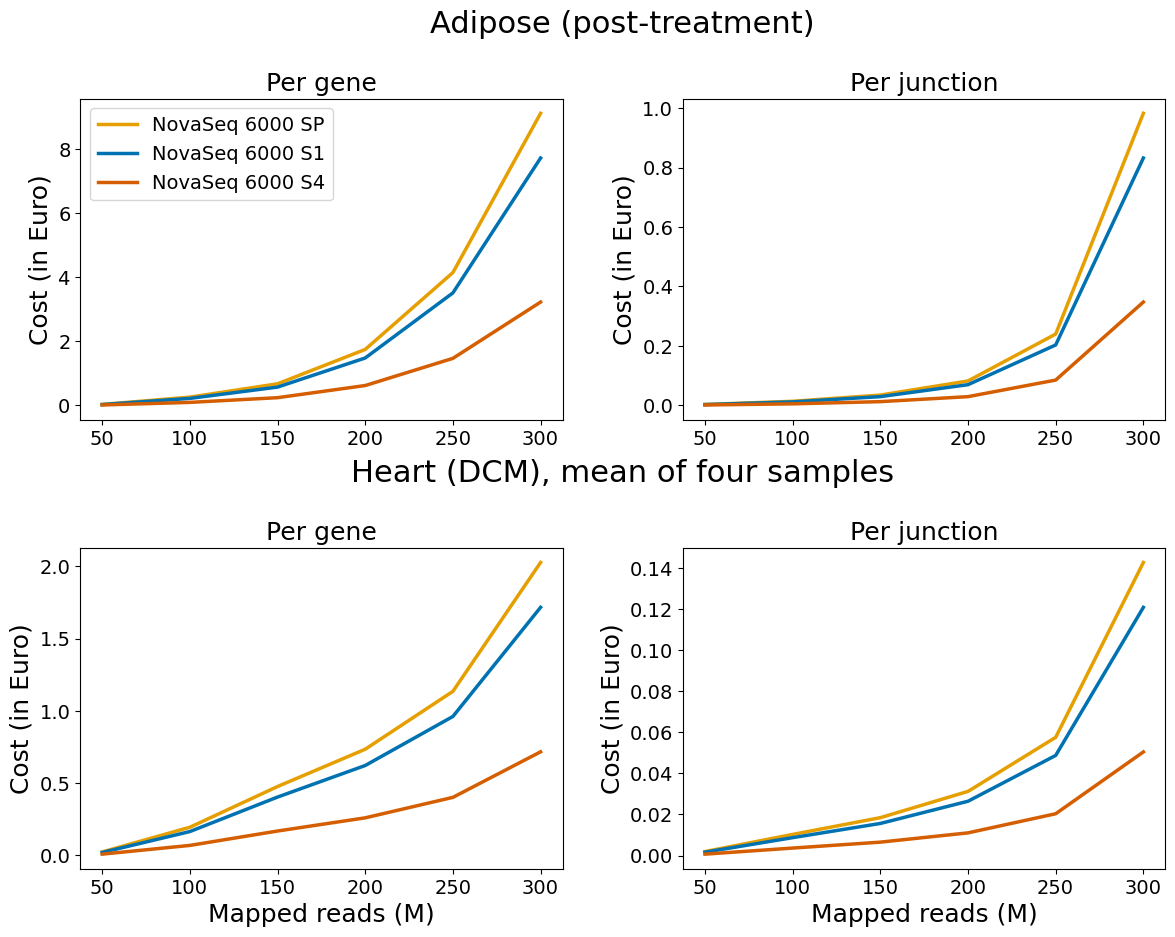

In [3]:
figure, axes_grid = plt.subplots(2, 2, figsize=(14, 10))
figure.subplots_adjust(hspace=0.4, wspace=0.25)

rows = []
for row, (row_title, panels) in enumerate(PANELS):
    for column, (subtitle, samples, kind) in enumerate(panels):
        axes = axes_grid[row, column]
        for name, values in cost_per_detection(samples, kind).items():
            axes.plot(
                DEPTHS // 1_000_000, values, linewidth=2.5, label=name,
                color=PLATFORM_COLORS[PLATFORMS[name]["key"]],
            )
            rows.extend(
                {"row": row_title, "panel": subtitle,
                 "samples": "+".join(samples), "kind": kind,
                 "platform": name, "depth_M": depth // 1_000_000, "euro": value}
                for depth, value in zip(DEPTHS, values)
            )
        axes.set_ylabel("Cost (in Euro)", fontsize=18)
        axes.set_title(subtitle, fontsize=18)
        axes.tick_params(labelsize=14)
        if row == 1:
            axes.set_xlabel("Mapped reads (M)", fontsize=18)
        if (row, column) == (0, 0):
            axes.legend(loc="upper left", fontsize=14)

    boxes = [axes.get_position() for axes in axes_grid[row]]
    figure.text(
        (min(b.x0 for b in boxes) + max(b.x1 for b in boxes)) / 2,
        max(b.y1 for b in boxes) + 0.06,
        row_title, ha="center", va="bottom", fontsize=22,
    )

figure.savefig(RESULTS / "Figure_7.png", dpi=300, bbox_inches="tight")
plt.show()

## Plotted values

In [4]:
costs = pd.DataFrame(rows)
costs.to_csv(RESULTS / "Figure_7_values.tsv", sep="\t", index=False)
costs.pivot_table(
    index=["panel", "samples", "kind", "depth_M"], columns="platform", values="euro"
).round(3)

platform                                                    NovaSeq 6000 S1  \
panel        samples                     kind      depth_M                    
Per gene     Adipose2                    genes     50                 0.022   
                                                   100                0.215   
                                                   150                0.568   
                                                   200                1.478   
                                                   250                3.512   
                                                   300                7.727   
             J26675+J26676+J26677+J26678 genes     50                 0.020   
                                                   100                0.165   
                                                   150                0.404   
                                                   200                0.622   
                                                   250                0.962   
                                                   300                1.717   
Per junction Adipose2                    junctions 50                 0.002   
                                                   100                0.011   
                                                   150                0.029   
                                                   200                0.069   
                                                   250                0.203   
                                                   300                0.832   
             J26675+J26676+J26677+J26678 junctions 50                 0.002   
                                                   100                0.009   
                                                   150                0.016   
                                                   200                0.026   
                                                   250                0.049   
                                                   300                0.121   

platform                                                    NovaSeq 6000 S4  \
panel        samples                     kind      depth_M                    
Per gene     Adipose2                    genes     50                 0.009   
                                                   100                0.090   
                                                   150                0.237   
                                                   200                0.617   
                                                   250                1.466   
                                                   300                3.226   
             J26675+J26676+J26677+J26678 genes     50                 0.008   
                                                   100                0.069   
                                                   150                0.168   
                                                   200                0.260   
                                                   250                0.401   
                                                   300                0.717   
Per junction Adipose2                    junctions 50                 0.001   
                                                   100                0.005   
                                                   150                0.012   
                                                   200                0.029   
                                                   250                0.085   
                                                   300                0.347   
             J26675+J26676+J26677+J26678 junctions 50                 0.001   
                                                   100                0.004   
                                                   150                0.007   
                                                   200                0.011   
                                                 